### Krylov Quantum Diagonalization (KQD)

In [1]:
import numpy as np
import matplotlib.pylab as plt
import warnings

from sympy import Matrix

from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from common.krylov_regularized_eigenvalues import single_particle_gs, solve_generalized_eig
from common.hamiltonians import get_heisenberg_hamiltonian_restricted_to_single_particle_states, \
    build_heisenberg_chain_hamiltonian
from common.time_evolution_circuit import build_efficient_time_evolution_circuit
from common.states import get_krylov_initial_state
from common.krylov_hadamard_test import get_parameters_for_template_circuit, build_modified_hadamard_test_circuit, \
    get_observables_S, get_observables_H, get_expectation_values_S, get_expectation_values_H
from common.expectations_processing import assemble_S_matrix, assemble_H_matrix

warnings.filterwarnings("ignore")

### 1: Map problem to quantum circuits and operators

In [2]:
# Define problem Hamiltonian.
n_qubits = 10
H_op = build_heisenberg_chain_hamiltonian(n_qubits)
H_op

SparsePauliOp(['ZZIIIIIIII', 'IZZIIIIIII', 'IIZZIIIIII', 'IIIZZIIIII', 'IIIIZZIIII', 'IIIIIZZIII', 'IIIIIIZZII', 'IIIIIIIZZI', 'IIIIIIIIZZ', 'XXIIIIIIII', 'IXXIIIIIII', 'IIXXIIIIII', 'IIIXXIIIII', 'IIIIXXIIII', 'IIIIIXXIII', 'IIIIIIXXII', 'IIIIIIIXXI', 'IIIIIIIIXX', 'YYIIIIIIII', 'IYYIIIIIII', 'IIYYIIIIII', 'IIIYYIIIII', 'IIIIYYIIII', 'IIIIIYYIII', 'IIIIIIYYII', 'IIIIIIIYYI', 'IIIIIIIIYY'],
              coeffs=[2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j, 2.+0.j,
 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j, 3.+0.j])

In [3]:
# Get Hamiltonian restricted to single-particle states
single_particle_H = get_heisenberg_hamiltonian_restricted_to_single_particle_states(n_qubits, H_op)

# Set dt according to spectral norm
dt = np.pi / np.linalg.norm(single_particle_H, ord=2)
dt

np.float64(0.17453292519943292)

In [4]:
# Set parameters for quantum Krylov algorithm
krylov_dim = 6  # size of krylov subspace
num_trotter_steps = 6
dt_circ = dt / num_trotter_steps

### 2. Optimize circuits and operators for target hardware

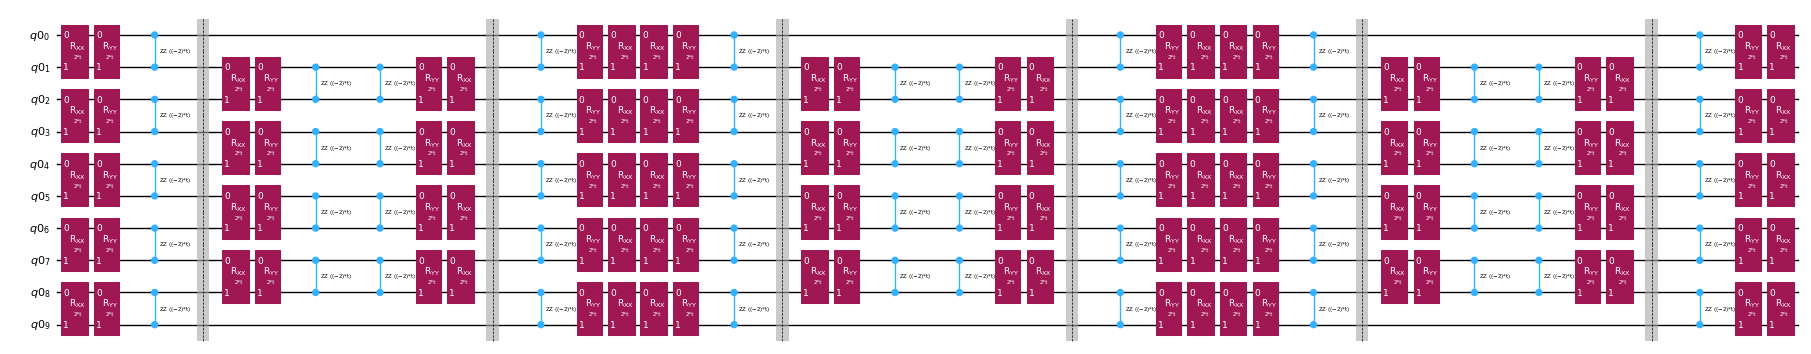

In [5]:
# Efficient Hadamard test
t = Parameter("t")
qc_evol = build_efficient_time_evolution_circuit(n_qubits, num_trotter_steps, t)
qc_evol.decompose().draw("mpl", fold=-1, scale=0.5)

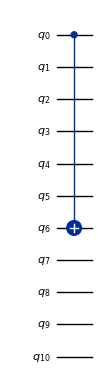

In [6]:
# initial state
controlled_state_prep = get_krylov_initial_state(n_qubits)
controlled_state_prep.draw("mpl", fold=-1, scale=0.5)

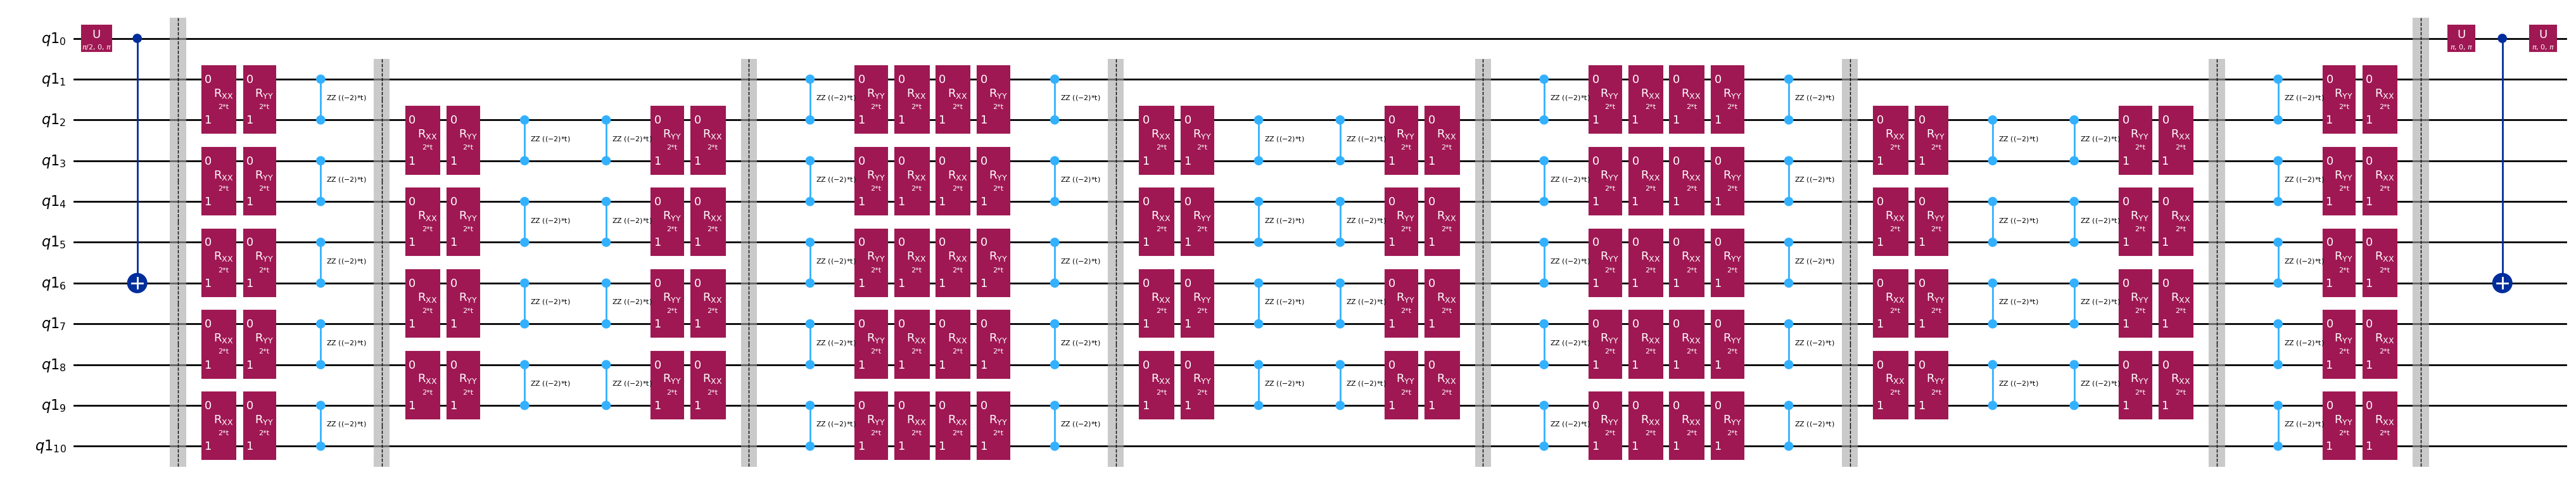

In [7]:
# Template circuits for calculating matrix elements of S~ and H~ via Hadamard test
# Parameters for the template circuits
parameters = get_parameters_for_template_circuit(krylov_dim, dt_circ)

qc = build_modified_hadamard_test_circuit(n_qubits, controlled_state_prep, qc_evol)
qc.decompose().draw("mpl", fold=-1)

In [8]:
print(
    "The optimized circuit has 2Q gates depth: ",
    qc.decompose().decompose().depth(lambda x: x[0].num_qubits == 2),
)

The optimized circuit has 2Q gates depth:  74


### 3. Execute using a Qiskit Runtime primitive

In [9]:
backend = AerSimulator()

In [10]:
target = backend.target
basis_gates = list(target.operation_names)
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    basis_gates=basis_gates
)

qc_trans = pm.run(qc)

38
OrderedDict({'rxx': 54, 'ryy': 54, 'rzz': 54, 'barrier': 8, 'cx': 2, 'x': 2, 'h': 1})


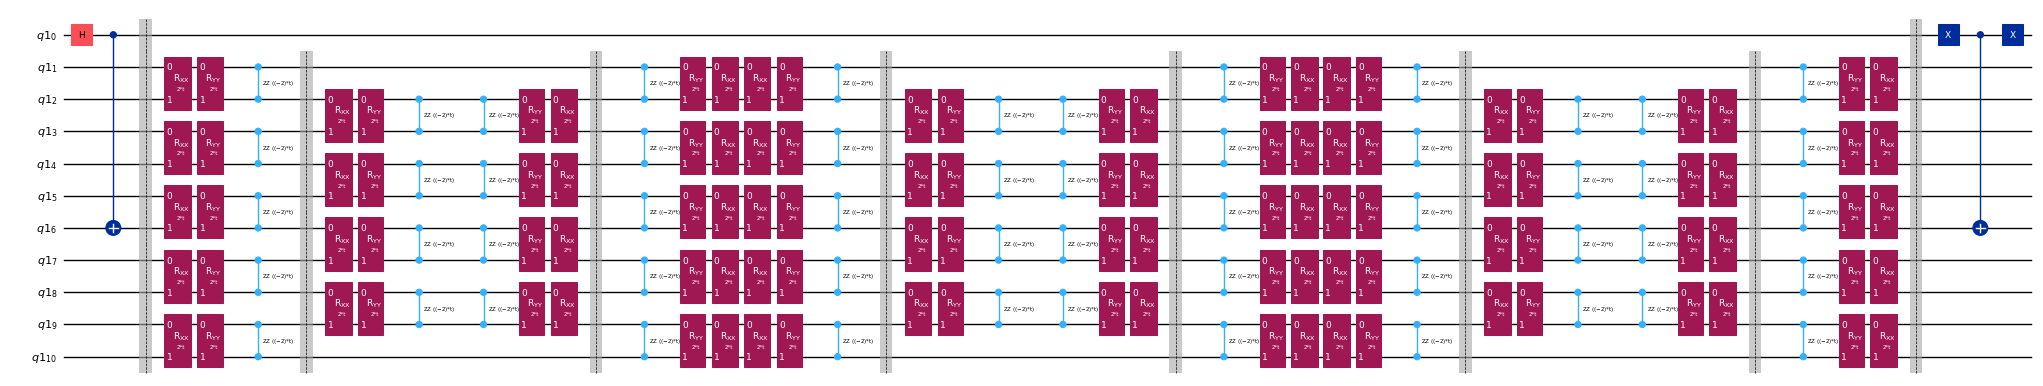

In [11]:
print(qc_trans.depth(lambda x: x[0].num_qubits == 2))
print(qc_trans.count_ops())
qc_trans.draw("mpl", fold=-1, idle_wires=False, scale=0.5)

In [12]:
# Define observables to measure for S
observables_S = get_observables_S(n_qubits, qc_trans)

# Define observables to measure for H
observables_H = get_observables_H(H_op, qc_trans)

# Define a sweep over parameter values
params = np.vstack(parameters).T

# Estimate the expectation value for all combinations of
# observables and parameter values, where the pub result will have
# shape (# observables, # parameter values).
pub = (qc_trans, observables_S + observables_H, params)

In [13]:
qc_cliff = qc.assign_parameters({t: 0})

# Get expectation values
S_expval = get_expectation_values_S(n_qubits, qc_cliff)
print(S_expval)

H_expval = get_expectation_values_H(H_op, qc_cliff)
print(H_expval)

(1+0j)
(10+0j)


In [14]:
# simulator
estimator = Estimator()

job = estimator.run([pub], precision=0.0)
results = job.result()[0]

### 4. Post-process and analyze results

In [15]:
# Calculate Effective Hamiltonian and Overlap matrices
prefactors = [
    np.exp(-1j * sum([c for p, c in H_op.to_list() if "Z" in p]) * i * dt)
    for i in range(1, krylov_dim)
]

In [16]:
S_circ = assemble_S_matrix(S_expval, results, krylov_dim, prefactors)
Matrix(S_circ)

Matrix([
[                                     1.0,  -0.67561063051885 + 0.566904630887815*I, 0.0991106780762911 - 0.562084586704051*I, 0.0887506998549536 + 0.153720721356076*I, 0.154333161776033 + 0.0561726770466669*I, -0.330517711571528 + 0.120298608909817*I],
[ -0.67561063051885 - 0.566904630887815*I,                                      1.0,  -0.67561063051885 + 0.566904630887815*I, 0.0991106780762911 - 0.562084586704051*I, 0.0887506998549536 + 0.153720721356076*I, 0.154333161776033 + 0.0561726770466669*I],
[0.0991106780762911 + 0.562084586704051*I,  -0.67561063051885 - 0.566904630887815*I,                                      1.0,  -0.67561063051885 + 0.566904630887815*I, 0.0991106780762911 - 0.562084586704051*I, 0.0887506998549536 + 0.153720721356076*I],
[0.0887506998549536 - 0.153720721356076*I, 0.0991106780762911 + 0.562084586704051*I,  -0.67561063051885 - 0.566904630887815*I,                                      1.0,  -0.67561063051885 + 0.566904630887815*I, 0.0991106780762911

In [17]:
H_eff_circ = assemble_H_matrix(H_expval, H_op, results, krylov_dim, prefactors)
Matrix(H_eff_circ)

Matrix([
[                                   10.0, -5.06916335333417 + 7.67946663225203*I, -3.26606862143479 - 6.37150075205638*I, 4.82276812919023 - 0.734816859546106*I, 0.406443541695579 + 3.68530108790177*I, -3.73163465484109 + 0.031303629993799*I],
[ -5.06916335333417 - 7.67946663225203*I,                                   10.0, -5.06916335333417 + 7.67946663225203*I, -3.26606862143479 - 6.37150075205638*I, 4.82276812919023 - 0.734816859546106*I,  0.406443541695579 + 3.68530108790177*I],
[ -3.26606862143479 + 6.37150075205638*I, -5.06916335333417 - 7.67946663225203*I,                                   10.0, -5.06916335333417 + 7.67946663225203*I, -3.26606862143479 - 6.37150075205638*I,  4.82276812919023 - 0.734816859546106*I],
[ 4.82276812919023 + 0.734816859546106*I, -3.26606862143479 + 6.37150075205638*I, -5.06916335333417 - 7.67946663225203*I,                                   10.0, -5.06916335333417 + 7.67946663225203*I,  -3.26606862143479 - 6.37150075205638*I],
[ 0.40644354169

In [18]:
#Finally, we can solve the generalized eigenvalue problem for H~:
# H~ c-> = c S c->
# and get an estimate of the ground state energy cmin
gnd_en_circ_est_list = solve_generalized_eig(H_eff_circ, S_circ, krylov_dim, threshold=1e-6)

Estimated ground state energy for d=1:  10.0
Estimated ground state energy for d=2:  4.43210850639871
Estimated ground state energy for d=3:  3.1753434524174478
Estimated ground state energy for d=4:  2.769448921349485
Estimated ground state energy for d=5:  2.67988802458575
Estimated ground state energy for d=6:  2.673933779125915


In [19]:
gs_en = single_particle_gs(H_op, n_qubits)

n_sys_qubits 10
n_exc 1 , subspace dimension 11
single particle ground state energy:  2.39154786963877


In [20]:
len(H_op)

27

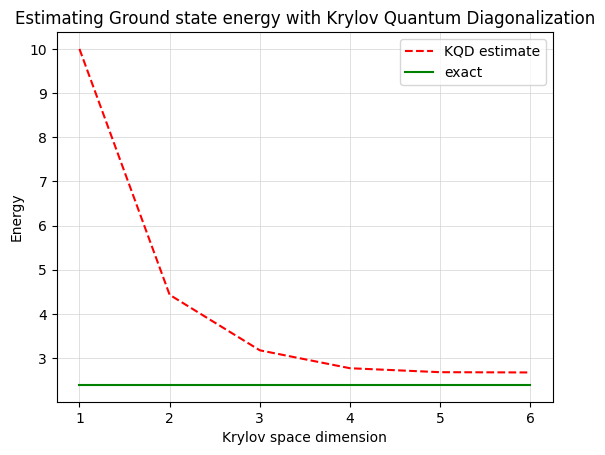

In [21]:
plt.plot(
    range(1, krylov_dim + 1),
    gnd_en_circ_est_list,
    color="red",
    linestyle="--",
    label="KQD estimate",
)
plt.plot(
    range(1, krylov_dim + 1),
    [gs_en] * krylov_dim,
    color="green",
    linestyle="-",
    label="exact",
)
plt.grid(True, which='both', color='lightgray', linestyle='-', linewidth=0.5, alpha=1)
plt.xticks(range(1, krylov_dim + 1), range(1, krylov_dim + 1))
plt.legend()
plt.xlabel("Krylov space dimension")
plt.ylabel("Energy [arb. u.]s")
plt.title("Estimating Ground state energy with Krylov Quantum Diagonalization")
plt.show()